In [75]:
import pandas as pd  

In [76]:
a = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\admissions.csv.gz")
a.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,NaN,NaN,0
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,NaN,UNKNOWN,NaN,NaN,1
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,P07HDB,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,NaN,NaN,0


In [77]:
p = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\patients.csv.gz")
p.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10014729,F,21,2125,2011 - 2013,NaN
1,10003400,F,72,2134,2011 - 2013,2137-09-02
2,10002428,F,80,2155,2011 - 2013,NaN
3,10032725,F,38,2143,2011 - 2013,2143-03-30
4,10027445,F,48,2142,2011 - 2013,2146-02-09


In [78]:
i = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\icustays.csv.gz")
i.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10018328,23786647,31269608,Neuro Stepdown,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Stepdown,2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662
2,10020187,26842957,32554129,Neuro Intermediate,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685
3,10012853,27882036,31338022,Trauma SICU (TSICU),Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725
4,10020740,25826145,32145159,Trauma SICU (TSICU),Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106


In [79]:
i["intime"] = pd.to_datetime(i["intime"])
i["outtime"] = pd.to_datetime(i["outtime"])
a["admittime"] = pd.to_datetime(a["admittime"])
a["dischtime"] = pd.to_datetime(a["dischtime"])


print(i["intime"].dtype)
print(i["outtime"].dtype)

print(a["admittime"].dtype)
print(a["dischtime"].dtype)

datetime64[ns]
datetime64[ns]
datetime64[ns]
datetime64[ns]


In [80]:
a["h_s"] = a["dischtime"] - a["admittime"]
print(a["h_s"].head())

i["i_s"] = i["outtime"] - i["intime"]
print(i["i_s"].head())

0   8 days 23:24:00
1   7 days 20:12:00
2   5 days 17:33:00
3   1 days 17:41:00
4   2 days 02:11:00
Name: h_s, dtype: timedelta64[ns]
0   7 days 16:51:37
1   5 days 10:51:50
2   0 days 20:56:40
3   3 days 18:24:05
4   1 days 00:53:26
Name: i_s, dtype: timedelta64[ns]


In [81]:
print(i["i_s"].count())
print(i["i_s"].min())
print(i["i_s"].max())
print(i["i_s"].mean())
print(i["i_s"].notna())
print(a["h_s"].count())
print(a["h_s"].min())
print(a["h_s"].max())
print(a["h_s"].mean())
print(a["h_s"].notna())

140
0 days 00:34:10
20 days 12:41:18
3 days 16:18:18.350000
0      True
1      True
2      True
3      True
4      True
       ... 
135    True
136    True
137    True
138    True
139    True
Name: i_s, Length: 140, dtype: bool
275
0 days 01:07:00
44 days 22:16:00
6 days 21:00:45.818181818
0      True
1      True
2      True
3      True
4      True
       ... 
270    True
271    True
272    True
273    True
274    True
Name: h_s, Length: 275, dtype: bool


In [82]:
# p["gender"].count()
p["male"] = p["gender"] == "M"
p["female"] = p["gender"] == "F"
p.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod,male,female
0,10014729,F,21,2125,2011 - 2013,NaN,False,True
1,10003400,F,72,2134,2011 - 2013,2137-09-02,False,True
2,10002428,F,80,2155,2011 - 2013,NaN,False,True
3,10032725,F,38,2143,2011 - 2013,2143-03-30,False,True
4,10027445,F,48,2142,2011 - 2013,2146-02-09,False,True


In [83]:
print(f"Male Patients Count = {p["male"].sum()}")
print(f"Female Patients Count = {p["female"].sum()}")

Male Patients Count = 57
Female Patients Count = 43


In [84]:
print(f"Minimum Age : {p["anchor_age"].min()}")
print(f"Maximum Age : {p["anchor_age"].max()}")
print(f"Average of Age : {p["anchor_age"].mean()}")


Minimum Age : 21
Maximum Age : 91
Average of Age : 61.75


In [85]:
p[["gender","anchor_age"]].groupby("gender").mean()

,anchor_age
gender,
F,60.813953
M,62.456140


In [86]:
new = pd.merge(p,a,how = "left",on = "subject_id")
new["h_s"].notna().sum()

np.int64(275)

In [87]:
print(new[["gender","h_s"]].groupby("gender").mean())


                             h_s
gender                          
F      6 days 05:46:03.609022556
M      7 days 11:17:29.577464788


In [88]:
new.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod,male,female,hadm_id,admittime,...,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,h_s
0,10014729,F,21,2125,2011 - 2013,NaN,False,True,23300884,2125-03-19 16:58:00,...,EMERGENCY ROOM,HOME HEALTH CARE,Other,ENGLISH,SINGLE,WHITE - OTHER EUROPEAN,2125-03-19 12:36:00,2125-03-19 18:45:00,0,8 days 20:39:00
1,10014729,F,21,2125,2011 - 2013,NaN,False,True,28889419,2125-02-27 07:15:00,...,PHYSICIAN REFERRAL,HOME HEALTH CARE,Other,ENGLISH,SINGLE,WHITE - OTHER EUROPEAN,NaN,NaN,0,7 days 07:10:00
2,10003400,F,72,2134,2011 - 2013,2137-09-02,False,True,23559586,2137-08-04 00:07:00,...,TRANSFER FROM HOSPITAL,DIED,Medicare,ENGLISH,MARRIED,BLACK/AFRICAN AMERICAN,NaN,NaN,1,29 days 16:58:00
3,10003400,F,72,2134,2011 - 2013,2137-09-02,False,True,20214994,2137-02-24 10:00:00,...,TRANSFER FROM SKILLED NURSING FACILITY,CHRONIC/LONG TERM ACUTE CARE,Medicare,ENGLISH,MARRIED,BLACK/AFRICAN AMERICAN,NaN,NaN,0,23 days 05:45:00
4,10003400,F,72,2134,2011 - 2013,2137-09-02,False,True,27296885,2136-12-31 21:40:00,...,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,BLACK/AFRICAN AMERICAN,2136-12-31 13:41:00,2137-01-01 00:35:00,0,2 days 19:25:00


In [89]:
def age_group(age):
    if 20 <= age <= 40:
        return "Young Adult"
    elif 41 <= age <= 60:
        return "Middle Age"
    elif 61 <= age <= 80:
        return "Senior"
    else:
        return "Elderly"
new["category"] = new["anchor_age"].apply(age_group)

In [90]:
new.groupby("category")["h_s"].mean()

category
Elderly          5 days 20:25:40.800000
Middle Age       6 days 09:38:31.680000
Senior        7 days 11:25:57.798165137
Young Adult      8 days 02:01:22.500000
Name: h_s, dtype: timedelta64[ns]

In [91]:
new.groupby(["gender","category"])["h_s"].mean()

gender  category   
F       Elderly       3 days 20:20:55.714285714
        Middle Age       5 days 15:17:07.500000
        Senior        6 days 23:43:23.389830508
        Young Adult             7 days 18:24:15
M       Elderly       8 days 09:37:10.909090909
        Middle Age    6 days 21:05:07.012987013
        Senior                  8 days 01:15:00
        Young Adult             9 days 00:52:45
Name: h_s, dtype: timedelta64[ns]

In [92]:
new["days"] = new["h_s"].dt.days
print(new["days"].head())
new[["anchor_age","h_s"]].corr()

0     8
1     7
2    29
3    23
4     2
Name: days, dtype: int64


,anchor_age,h_s
anchor_age,1.000000,-0.027647
h_s,-0.027647,1.000000


In [93]:
i = i.drop(columns=["stay_id"])
i.head()

,subject_id,hadm_id,first_careunit,last_careunit,intime,outtime,los,i_s
0,10018328,23786647,Neuro Stepdown,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512,7 days 16:51:37
1,10020187,24104168,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Stepdown,2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662,5 days 10:51:50
2,10020187,26842957,Neuro Intermediate,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685,0 days 20:56:40
3,10012853,27882036,Trauma SICU (TSICU),Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725,3 days 18:24:05
4,10020740,25826145,Trauma SICU (TSICU),Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106,1 days 00:53:26


In [94]:
a.head()


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,h_s
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0,8 days 23:24:00
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,NaN,NaN,0,7 days 20:12:00
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0,5 days 17:33:00
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,NaN,UNKNOWN,NaN,NaN,1,1 days 17:41:00
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,P07HDB,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,NaN,NaN,0,2 days 02:11:00


In [95]:
a = a.drop(columns=["race","hadm_id","admission_location","discharge_location","insurance","marital_status","deathtime","admission_type","language","edregtime","edouttime","hospital_expire_flag"])

In [96]:
a.head()

,subject_id,admittime,dischtime,admit_provider_id,h_s
0,10004235,2196-02-24 14:38:00,2196-03-04 14:02:00,P03YMR,8 days 23:24:00
1,10009628,2153-09-17 17:08:00,2153-09-25 13:20:00,P41R5N,7 days 20:12:00
2,10018081,2134-08-18 02:02:00,2134-08-23 19:35:00,P233F6,5 days 17:33:00
3,10006053,2111-11-13 23:39:00,2111-11-15 17:20:00,P38TI6,1 days 17:41:00
4,10031404,2113-08-04 18:46:00,2113-08-06 20:57:00,P07HDB,2 days 02:11:00


In [97]:
a=a.drop(columns="admit_provider_id")

In [98]:
a.head()

,subject_id,admittime,dischtime,h_s
0,10004235,2196-02-24 14:38:00,2196-03-04 14:02:00,8 days 23:24:00
1,10009628,2153-09-17 17:08:00,2153-09-25 13:20:00,7 days 20:12:00
2,10018081,2134-08-18 02:02:00,2134-08-23 19:35:00,5 days 17:33:00
3,10006053,2111-11-13 23:39:00,2111-11-15 17:20:00,1 days 17:41:00
4,10031404,2113-08-04 18:46:00,2113-08-06 20:57:00,2 days 02:11:00


In [99]:
new1 = pd.merge(a,i,how="left",on="subject_id")
new1.head()

,subject_id,admittime,dischtime,h_s,hadm_id,first_careunit,last_careunit,intime,outtime,los,i_s
0,10004235,2196-02-24 14:38:00,2196-03-04 14:02:00,8 days 23:24:00,24181354,Coronary Care Unit (CCU),Medical Intensive Care Unit (MICU),2196-02-24 17:07:00,2196-02-29 15:58:02,4.952106,4 days 22:51:02
1,10009628,2153-09-17 17:08:00,2153-09-25 13:20:00,7 days 20:12:00,25926192,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2153-09-19 09:54:49,2153-09-21 16:39:06,2.280752,2 days 06:44:17
2,10018081,2134-08-18 02:02:00,2134-08-23 19:35:00,5 days 17:33:00,28861356,Trauma SICU (TSICU),Trauma SICU (TSICU),2134-08-05 14:53:33,2134-08-07 17:32:43,2.110532,2 days 02:39:10
3,10018081,2134-08-18 02:02:00,2134-08-23 19:35:00,5 days 17:33:00,21027282,Trauma SICU (TSICU),Trauma SICU (TSICU),2133-12-18 17:10:00,2134-01-01 14:44:53,13.899225,13 days 21:34:53
4,10006053,2111-11-13 23:39:00,2111-11-15 17:20:00,1 days 17:41:00,22942076,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2111-11-14 00:19:12,2111-11-15 18:21:10,1.751366,1 days 18:01:58


In [100]:
new1["h_sdays"] = new1["h_s"].dt.days
new1["i_sdays"] = new1["i_s"].dt.days

In [48]:
new1[["h_sdays","i_sdays"]].corr()

,h_sdays,i_sdays
h_sdays,1.000000,0.232744
i_sdays,0.232744,1.000000


In [49]:
import matplotlib.pyplot as plt

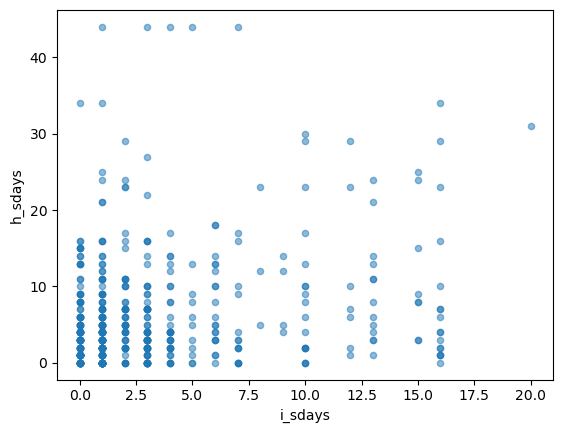

In [50]:
new1.plot.scatter(x="i_sdays",y="h_sdays",alpha=0.5)
plt.show()

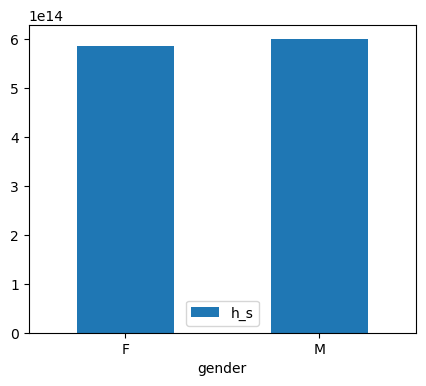

In [55]:
fig,axs = plt.subplots(figsize =(5,4))
new[["gender","h_s"]].groupby("gender").mean().plot(kind="bar",rot=0,ax=axs)
plt.show()

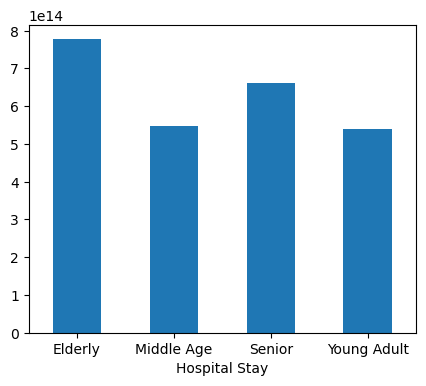

In [68]:
fig,axs = plt.subplots(figsize=(5,4))
new.groupby(["category"])["h_s"].mean().plot(kind="bar",rot=0,ax=axs)
plt.xlabel("Hospital Stay")
plt.show()

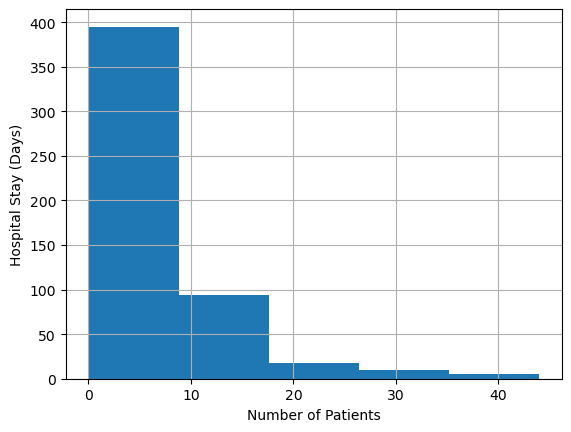

In [69]:
new1["h_s"].dt.days.hist(bins=5)

plt.ylabel("Hospital Stay (Days)")
plt.xlabel("Number of Patients")
plt.show()

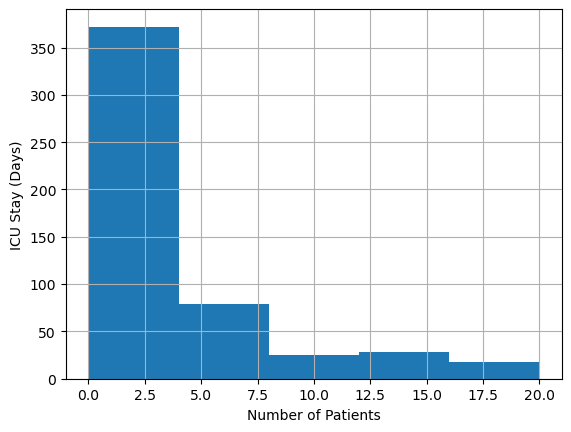

In [70]:
new1["i_s"].dt.days.hist(bins=5)

plt.ylabel("ICU Stay (Days)")
plt.xlabel("Number of Patients")
plt.show()

<Axes: xlabel='anchor_age', ylabel='h_sdays'>

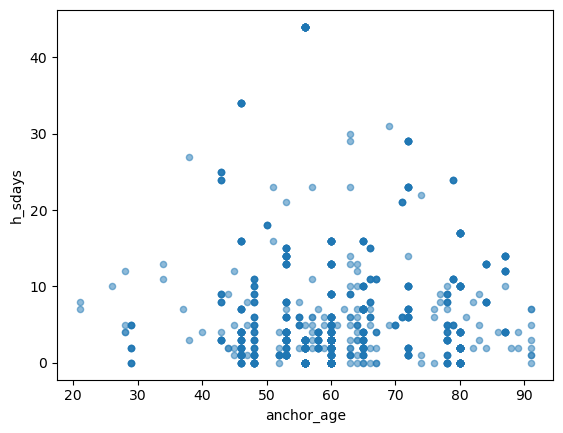

In [74]:
new["h_sdays"] = new["h_s"].dt.days
new.plot.scatter(x="anchor_age",y="h_sdays",alpha=0.5)
